# EcoPack Predictor Accuracy

This notebook evaluates the first prediction-accuracy metric for EcoPack's normalized-runtime predictor.

For each application and GPU count, it reproduces the predictor used in `ecoPack.py`:

Then it compares using min-max normalization:
- predicted normalized runtime: `(max(signal) - signal) / (max(signal) - min(signal))`
- true normalized runtime: `(runtime - min(runtime)) / (max(runtime) - min(runtime))`

Main metrics in this first version:
- MAE
- RMSE


In [1]:
from pathlib import Path
import math
import re

import pandas as pd

DATA_ROOT = Path('/home/ac.zzheng/power/GPGPU/coSched/data')
SYSTEMS = ['H100','A100','V100']
SECTION_RE = re.compile(r'^===== .*?/([^/ ]+) =====$')
SM_OVERRIDE_APPS = {
    'simpleCUBLASXT',
    'simpleCUFFT_2d_MGPU',
    'simpleCUFFT_MGPU',
    'miniweather',
}
DRAM_SM_THRESHOLD = 0.001


In [2]:
def parse_perf_metrics(metrics_path: Path):
    rows = []
    current_app = None

    for raw_line in metrics_path.read_text().splitlines():
        line = raw_line.strip()
        if not line:
            continue

        match = SECTION_RE.match(line)
        if match:
            current_app = match.group(1)
            continue

        if current_app is None or line.startswith('cap=') or line.startswith('gpu_count'):
            continue

        parts = line.split()
        if len(parts) < 6:
            raise ValueError(f'Expected 6 columns in {metrics_path}, got {len(parts)} for line: {line}')

        rows.append({
            'app': current_app,
            'gpu_count': int(parts[0]),
            'runtime_s': float(parts[1]),
            'avg_power_w': float(parts[2]),
            'dram_sum': float(parts[3]),
            'sm_sum': float(parts[4]),
            'fp_sum': float(parts[5]),
        })

    return pd.DataFrame(rows).sort_values(['app', 'gpu_count']).reset_index(drop=True)


def predictor_name_and_values(app_df: pd.DataFrame):
    app = app_df['app'].iloc[0]

    sm_per_gpu = {
        int(row.gpu_count): row.sm_sum / float(row.gpu_count)
        for row in app_df.itertuples(index=False)
    }
    if app in SM_OVERRIDE_APPS:
        return 'sm_sum/gpu_count (override)', sm_per_gpu

    dram_values = dict(zip(app_df['gpu_count'], app_df['dram_sum']))
    if any(value < DRAM_SM_THRESHOLD for value in dram_values.values()):
        return f'sm_sum/gpu_count (dram<{DRAM_SM_THRESHOLD})', sm_per_gpu
    if any(value > 0.0 for value in dram_values.values()):
        return 'dram_sum', dram_values

    fp_per_gpu = {
        int(row.gpu_count): row.fp_sum / float(row.gpu_count)
        for row in app_df.itertuples(index=False)
    }
    if any(value > 0.0 for value in fp_per_gpu.values()):
        return 'fp_sum/gpu_count', fp_per_gpu

    return 'sm_sum/gpu_count', sm_per_gpu


def predicted_norm_runtime(predictor_values):
    min_value = min(predictor_values.values())
    max_value = max(predictor_values.values())

    if abs(max_value - min_value) < 1e-12:
        return {gpu_count: 0.0 for gpu_count in predictor_values}

    return {
        gpu_count: (max_value - value) / (max_value - min_value)
        for gpu_count, value in predictor_values.items()
    }



def build_prediction_frame(system: str):
    metrics_path = DATA_ROOT / system / 'perf_metrics.txt'
    df = parse_perf_metrics(metrics_path)
    rows = []

    for app, app_df in df.groupby('app', sort=True):
        predictor_name, predictor_values = predictor_name_and_values(app_df)
        pred_nrt = predicted_norm_runtime(predictor_values)
        runtime_values = {
            int(row.gpu_count): row.runtime_s
            for row in app_df.itertuples(index=False)
        }
        min_runtime = min(runtime_values.values())
        max_runtime = max(runtime_values.values())
        if abs(max_runtime - min_runtime) < 1e-12:
            true_norm = {gpu_count: 0.0 for gpu_count in runtime_values}
        else:
            true_norm = {
                gpu_count: (runtime - min_runtime) / (max_runtime - min_runtime)
                for gpu_count, runtime in runtime_values.items()
            }

        for row in app_df.itertuples(index=False):
            gpu_count = int(row.gpu_count)
            true_nrt = true_norm[gpu_count]
            pred = pred_nrt[gpu_count]
            rows.append({
                'system': system,
                'app': app,
                'gpu_count': gpu_count,
                'runtime_s': row.runtime_s,
                'true_norm_runtime': true_nrt,
                'pred_norm_runtime': pred,
                'abs_error': abs(pred - true_nrt),
                'sq_error': (pred - true_nrt) ** 2,
                'predictor': predictor_name,
            })

    return pd.DataFrame(rows).sort_values(['app', 'gpu_count']).reset_index(drop=True)


In [7]:
prediction_frames = {system: build_prediction_frame(system) for system in SYSTEMS}
all_predictions = pd.concat(prediction_frames.values(), ignore_index=True)

summary_rows = []
for system, frame in prediction_frames.items():
    summary_rows.append({
        'system': system,
        'num_apps': frame['app'].nunique(),
        'num_points': len(frame),
        'mae': frame['abs_error'].mean(),
        'rmse': math.sqrt(frame['sq_error'].mean()),
    })

summary_df = pd.DataFrame(summary_rows).sort_values('system').reset_index(drop=True)
summary_df


,system,num_apps,num_points,mae,rmse
0,A100,18,66,0.176877,0.314739
1,H100,17,62,0.125206,0.254643
2,V100,17,61,0.184943,0.319010


In [8]:
app_summary_rows = []
for system, frame in prediction_frames.items():
    grouped = frame.groupby('app', sort=True)
    for app, app_df in grouped:
        app_summary_rows.append({
            'system': system,
            'app': app,
            'num_points': len(app_df),
            'predictor': app_df['predictor'].iloc[0],
            'mae': app_df['abs_error'].mean(),
            'rmse': math.sqrt(app_df['sq_error'].mean()),
        })

app_summary_df = pd.DataFrame(app_summary_rows).sort_values(['system', 'rmse', 'app']).reset_index(drop=True)
# app_summary_df


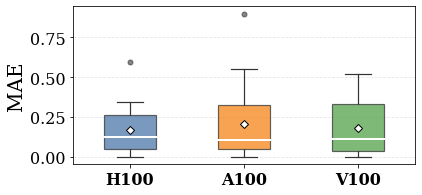

In [7]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 16,
    'axes.spines.top': True,
    'axes.spines.right': True,
})

mae_ratio_df = app_summary_ratio_df[['system', 'app', 'mae']].copy()
system_order = ['H100','A100','V100']
colors = ['#4C78A8', '#F58518', '#54A24B']

data = [mae_ratio_df.loc[mae_ratio_df['system'] == s, 'mae'].values for s in system_order]

fig, ax = plt.subplots(figsize=(6, 3))

bp = ax.boxplot(
    data, patch_artist=True, showmeans=True, widths=0.45,
    flierprops=dict(marker='o', markerfacecolor='#333333', markeredgecolor='#333333', markersize=5, alpha=0.6),
    meanprops=dict(marker='D', markerfacecolor='white', markeredgecolor='black', markersize=5, zorder=4),
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(color='#333333', linewidth=1.2),
    capprops=dict(color='#333333', linewidth=1.2),
    boxprops=dict(linewidth=1.2),
)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor('#333333')
    patch.set_alpha(0.75)

# Label outlier points with app names
for idx, system in enumerate(system_order):
    subset = mae_ratio_df[mae_ratio_df['system'] == system]
    q1 = subset['mae'].quantile(0.25)
    q3 = subset['mae'].quantile(0.75)
    cutoff = q3 + 1.5 * (q3 - q1)
    outliers = subset[subset['mae'] > cutoff]

ax.set_xticks(range(1, len(system_order) + 1))
ax.set_xticklabels(system_order, fontweight='bold')
ax.set_ylabel('MAE', fontsize=20)
# ax.set_title('Ratio Normalization', fontsize=13, fontweight='bold', pad=10)
ax.grid(axis='y', linestyle='--', alpha=0.25, color='#999999')
ax.set_axisbelow(True)
plt.savefig('../fig/mae_boxplot.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [9]:
import numpy as np
import matplotlib.pyplot as plt
def build_prediction_frame_poly(system: str, degree: int = 2, clip: bool = True):
    metrics_path = DATA_ROOT / system / 'perf_metrics.txt'
    df = parse_perf_metrics(metrics_path)
    rows = []

    for app, app_df in df.groupby('app', sort=True):
        predictor_name, predictor_values = predictor_name_and_values(app_df)
        runtime_values = {
            int(row.gpu_count): row.runtime_s
            for row in app_df.itertuples(index=False)
        }
        min_runtime = min(runtime_values.values())
        max_runtime = max(runtime_values.values())
        if abs(max_runtime - min_runtime) < 1e-12:
            true_norm = {gpu_count: 0.0 for gpu_count in runtime_values}
        else:
            true_norm = {
                gpu_count: (runtime - min_runtime) / (max_runtime - min_runtime)
                for gpu_count, runtime in runtime_values.items()
            }

        gpu_counts = sorted(predictor_values)
        x = np.array([predictor_values[g] for g in gpu_counts], dtype=float)
        y = np.array([true_norm[g] for g in gpu_counts], dtype=float)
        fit_degree = min(degree, len(gpu_counts) - 1, len(np.unique(x)) - 1)

        if fit_degree <= 0:
            pred = np.full_like(y, fill_value=float(np.mean(y)), dtype=float)
            coeffs = [float(np.mean(y))]
        else:
            coeffs = np.polyfit(x, y, deg=fit_degree)
            pred = np.polyval(coeffs, x)

        if clip:
            pred = np.clip(pred, 0.0, 1.0)

        pred_nrt = {gpu_count: float(pred[idx]) for idx, gpu_count in enumerate(gpu_counts)}

        for row in app_df.itertuples(index=False):
            gpu_count = int(row.gpu_count)
            true_nrt = true_norm[gpu_count]
            pred_value = pred_nrt[gpu_count]
            rows.append({
                'system': system,
                'app': app,
                'gpu_count': gpu_count,
                'runtime_s': row.runtime_s,
                'true_norm_runtime': true_nrt,
                'pred_norm_runtime': pred_value,
                'abs_error': abs(pred_value - true_nrt),
                'sq_error': (pred_value - true_nrt) ** 2,
                'predictor': predictor_name,
                'fit_degree': fit_degree,
            })

    return pd.DataFrame(rows).sort_values(['app', 'gpu_count']).reset_index(drop=True)


prediction_frames_poly = {system: build_prediction_frame_poly(system, degree=2) for system in SYSTEMS}

poly_summary_rows = []
for system, frame in prediction_frames_poly.items():
    poly_summary_rows.append({
        'system': system,
        'num_apps': frame['app'].nunique(),
        'num_points': len(frame),
        'mae': frame['abs_error'].mean(),
        'rmse': math.sqrt(frame['sq_error'].mean()),
    })

poly_summary_df = pd.DataFrame(poly_summary_rows).sort_values('system').reset_index(drop=True)
poly_summary_df


,system,num_apps,num_points,mae,rmse
0,A100,18,66,0.070446,0.128822
1,H100,17,62,0.044037,0.111622
2,V100,17,61,0.051197,0.107030


In [10]:
comparison_df = summary_df[['system', 'mae', 'rmse']].rename(columns={'mae': 'linear_mae', 'rmse': 'linear_rmse'})
comparison_df = comparison_df.merge(
    poly_summary_df[['system', 'mae', 'rmse']].rename(columns={'mae': 'poly_mae', 'rmse': 'poly_rmse'}),
    on='system',
    how='inner',
)
comparison_df['mae_gain'] = comparison_df['linear_mae'] - comparison_df['poly_mae']
comparison_df['rmse_gain'] = comparison_df['linear_rmse'] - comparison_df['poly_rmse']
comparison_df


,system,linear_mae,linear_rmse,poly_mae,poly_rmse,mae_gain,rmse_gain
0,A100,0.176877,0.314739,0.070446,0.128822,0.106431,0.185917
1,H100,0.125206,0.254643,0.044037,0.111622,0.081169,0.143021
2,V100,0.184943,0.319010,0.051197,0.107030,0.133746,0.211980


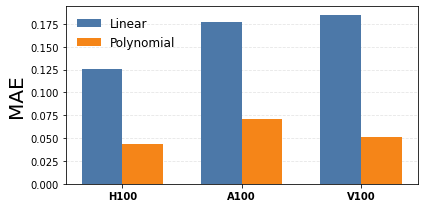

In [11]:
fig, ax = plt.subplots(figsize=(6, 3))
x = np.arange(len(SYSTEMS))
plot_order = ['H100', 'A100', 'V100']
linear_vals = [comparison_df.loc[comparison_df['system'] == s, 'linear_mae'].iloc[0] for s in plot_order]
poly_vals = [comparison_df.loc[comparison_df['system'] == s, 'poly_mae'].iloc[0] for s in plot_order]
width = 0.34
ax.bar(x - width/2, linear_vals, width=width, color='#4C78A8', label='Linear')
ax.bar(x + width/2, poly_vals, width=width, color='#F58518', label='Polynomial')
ax.set_xticks(x)
ax.set_xticklabels(plot_order, fontweight='bold')
ax.set_ylabel('MAE', fontsize=20)
ax.grid(axis='y', linestyle='--', alpha=0.25, color='#999999')
ax.set_axisbelow(True)
ax.legend(frameon=False, fontsize=12)
plt.tight_layout()
plt.show()


In [ ]:

# Per-app MAE summary for polynomial fit
app_summary_poly_rows = []
for system, frame in prediction_frames_poly.items():
    for app, app_df in frame.groupby('app', sort=True):
        app_summary_poly_rows.append({
            'system': system,
            'app': app,
            'mae': app_df['abs_error'].mean(),
        })
app_summary_poly_df = pd.DataFrame(app_summary_poly_rows)

system_order = ['H100', 'A100', 'V100']
colors = ['#4C78A8', '#F58518', '#54A24B']

data = [app_summary_poly_df.loc[app_summary_poly_df['system'] == s, 'mae'].values for s in system_order]

fig, ax = plt.subplots(figsize=(6, 3))

bp = ax.boxplot(
    data, patch_artist=True, showmeans=True, widths=0.45,
    flierprops=dict(marker='o', markerfacecolor='#333333', markeredgecolor='#333333', markersize=5, alpha=0.6),
    meanprops=dict(marker='D', markerfacecolor='white', markeredgecolor='black', markersize=5, zorder=4),
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(color='#333333', linewidth=1.2),
    capprops=dict(color='#333333', linewidth=1.2),
    boxprops=dict(linewidth=1.2),
)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor('#333333')
    patch.set_alpha(0.75)

ax.set_xticks(range(1, len(system_order) + 1))
ax.set_xticklabels(system_order, fontweight='bold')
ax.set_ylabel('MAE', fontsize=20)
ax.grid(axis='y', linestyle='--', alpha=0.25, color='#999999')
ax.set_axisbelow(True)
plt.savefig('../fig/mae_boxplot_poly.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()
